# Supermarket Sales Analysis

### Step 1 - Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded")

Libraries loaded


### Step 2 - Load the raw dataset

In [3]:
df = pd.read_csv("raw_supermarket_sales.csv")
print(df.shape)
df.head()

(1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### Step 3 — Check missing values

In [4]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Missing values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Duplicate rows: 0

Dtypes:
 Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                     

### Step 4 - Clean column names

In [5]:
df.columns = [c.strip().replace(" ", "_").replace("%", "Pct") for c in df.columns]
df.rename(columns={"Tax_5Pct": "Tax"}, inplace=True)
df.columns.tolist()

['Invoice_ID',
 'Branch',
 'City',
 'Customer_type',
 'Gender',
 'Product_line',
 'Unit_price',
 'Quantity',
 'Tax',
 'Total',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross_margin_percentage',
 'gross_income',
 'Rating']

### Step 5 - Parse Date and Time properly

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M").dt.time
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))

df["Day"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month_name()
df["Hour"] = df["Datetime"].dt.hour

df[["Date", "Time", "Day", "Month", "Hour"]].head()

,Date,Time,Day,Month,Hour
0,2019-01-05,13:08:00,Saturday,January,13
1,2019-03-08,10:29:00,Friday,March,10
2,2019-03-03,13:23:00,Sunday,March,13
3,2019-01-27,20:33:00,Sunday,January,20
4,2019-02-08,10:37:00,Friday,February,10


### Step 6 - Derived business columns

In [7]:
df["ProfitMarginPct"] = (df["gross_income"] / df["Total"] * 100).round(2)
df["AvgItemPrice"] = (df["Total"] / df["Quantity"]).round(2)

df.rename(columns={
    "cogs": "COGS",
    "gross_income": "GrossIncome",
    "gross_margin_percentage": "GrossMarginPct"
}, inplace=True)

df.head()

,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax,Total,...,COGS,GrossMarginPct,GrossIncome,Rating,Datetime,Day,Month,Hour,ProfitMarginPct,AvgItemPrice
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,Saturday,January,13,4.76,78.42
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,Friday,March,10,4.76,16.04
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,Sunday,March,13,4.76,48.65
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,Sunday,January,20,4.76,61.13
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,Friday,February,10,4.76,90.63


### Step 7 - Final column check

In [8]:
df = df.drop_duplicates()
df.to_csv("cleaned_supermarket_sales.csv", index=False)
print(f"Final rows: {len(df)}")
print("Saved -> cleaned_supermarket_sales.csv")

Final rows: 1000
Saved -> cleaned_supermarket_sales.csv


---
## EDA Phase

### Step 8 - Sales by Product Line

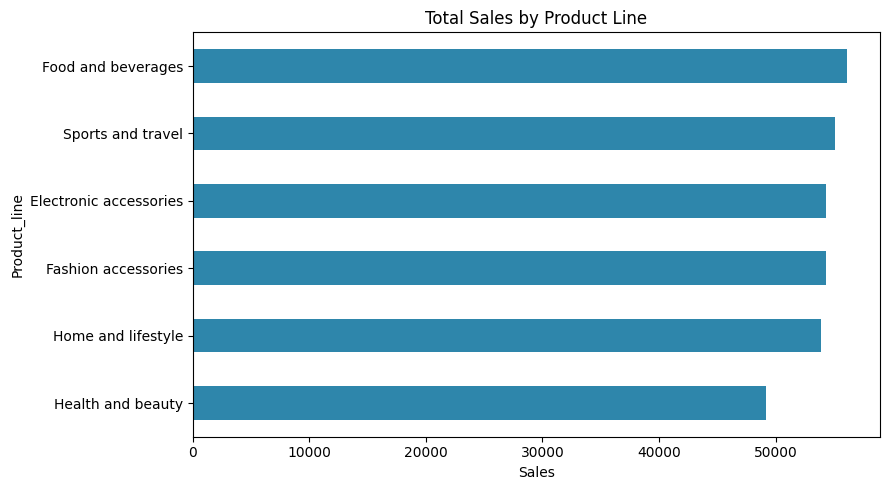

In [9]:
product_sales = df.groupby("Product_line")["Total"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
product_sales.plot(kind="barh", color="#2E86AB")
plt.title("Total Sales by Product Line")
plt.xlabel("Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 9 - Sales by City / Branch

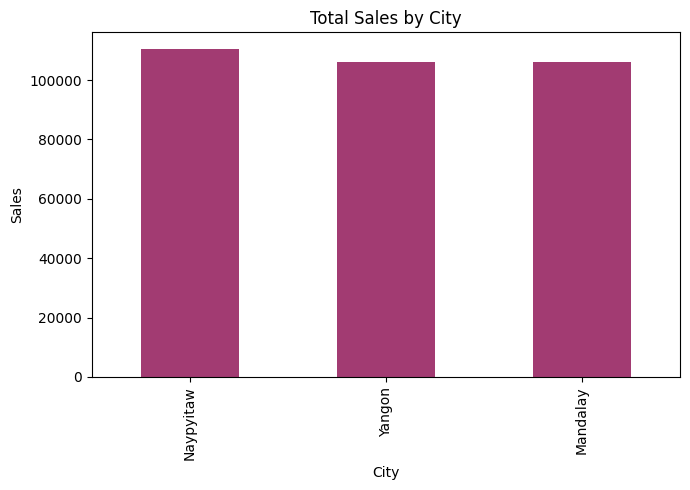

In [10]:
city_sales = df.groupby("City")["Total"].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
city_sales.plot(kind="bar", color="#A23B72")
plt.title("Total Sales by City")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Step 10 - Revenue by Payment Method

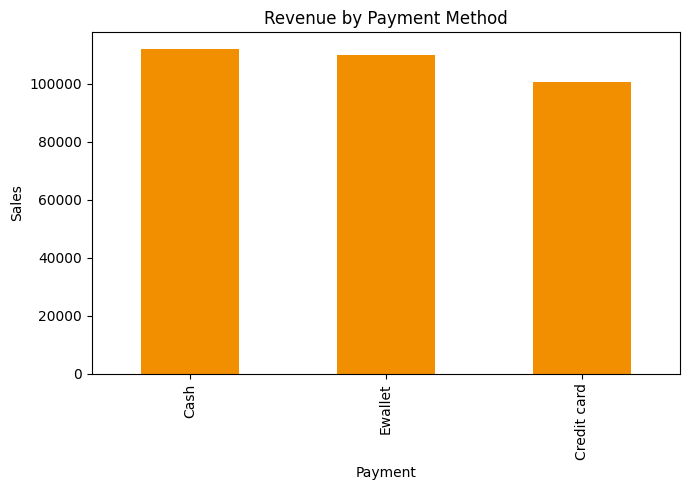

In [11]:
payment_sales = df.groupby("Payment")["Total"].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
payment_sales.plot(kind="bar", color="#F18F01")
plt.title("Revenue by Payment Method")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Step 11 - Customer Rating Distribution

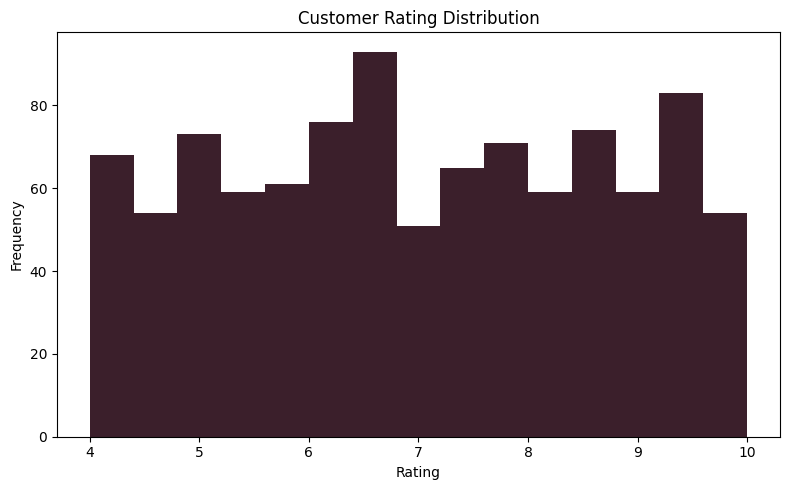

In [12]:
plt.figure(figsize=(8,5))
df["Rating"].plot(kind="hist", bins=15, color="#3B1F2B")
plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.tight_layout()
plt.show()

### Step 12 - Daily Sales Trend

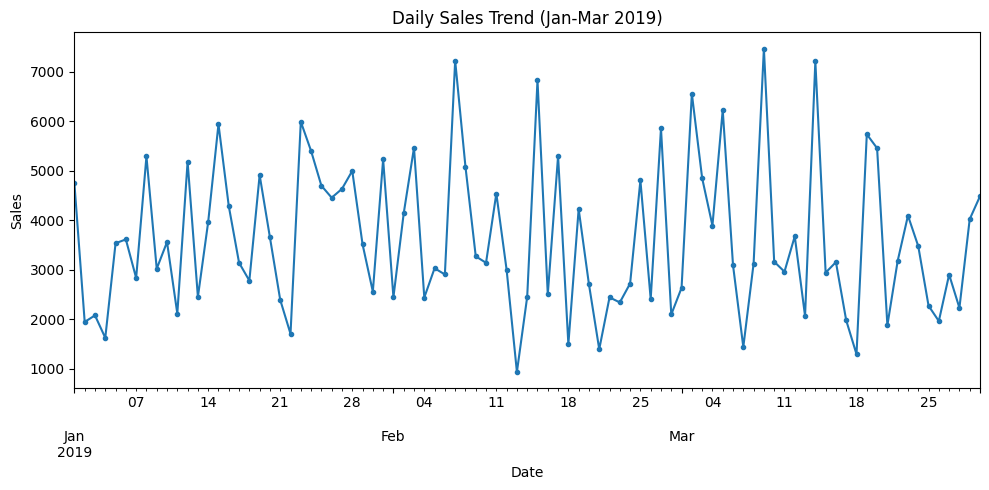

In [13]:
daily_sales = df.groupby("Date")["Total"].sum()
plt.figure(figsize=(10,5))
daily_sales.plot(kind="line", marker="o", markersize=3)
plt.title("Daily Sales Trend (Jan-Mar 2019)")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Step 13 - Gross Income by Product Line

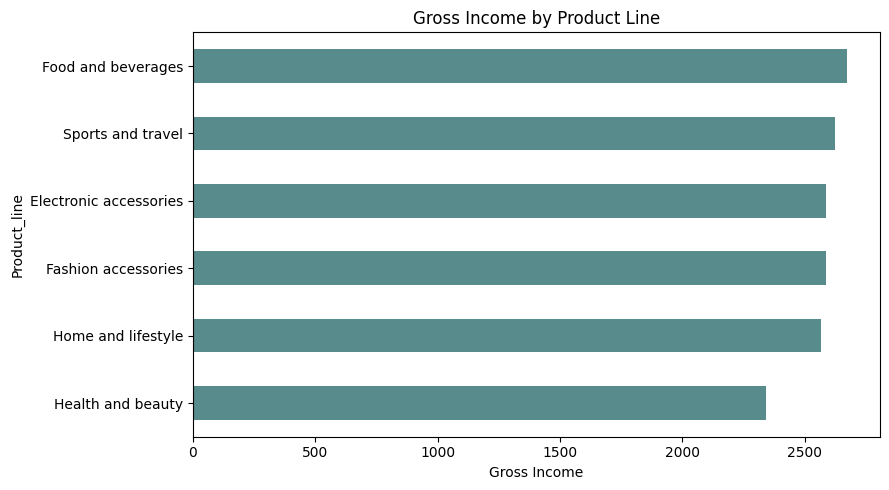

In [14]:
income_by_line = df.groupby("Product_line")["GrossIncome"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
income_by_line.plot(kind="barh", color="#588B8B")
plt.title("Gross Income by Product Line")
plt.xlabel("Gross Income")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 14 - Sales by Gender and Customer Type

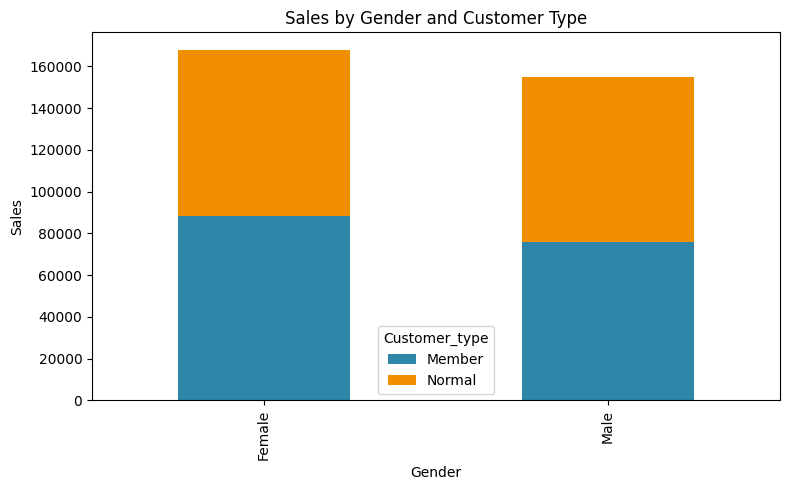

In [15]:
gender_ct = df.groupby(["Gender", "Customer_type"])["Total"].sum().unstack()
gender_ct.plot(kind="bar", stacked=True, figsize=(8,5), color=["#2E86AB", "#F18F01"])
plt.title("Sales by Gender and Customer Type")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

### Step 15 - Key Insights

In [16]:
print("KEY INSIGHTS:-")
print(f"Top product line: {product_sales.idxmax()} ({product_sales.max():,.0f})")
print(f"Top city: {city_sales.idxmax()} ({city_sales.max():,.0f})")
print(f"Most used payment method: {payment_sales.idxmax()}")
print(f"Average customer rating: {df['Rating'].mean():.2f}")
print(f"Best sales day: {daily_sales.idxmax().date()} ({daily_sales.max():,.0f})")
print(f"Highest margin product line: {income_by_line.idxmax()}")

KEY INSIGHTS:-
Top product line: Food and beverages (56,145)
Top city: Naypyitaw (110,569)
Most used payment method: Cash
Average customer rating: 6.97
Best sales day: 2019-03-09 (7,474)
Highest margin product line: Food and beverages
